In [6]:
# LightGBM vs XGBoost on Kennedy Space Center (KSC) Dataset
# Google Colab Notebook

# Install required packages
# !pip install lightgbm xgboost scikit-learn matplotlib seaborn pandas numpy scipy

# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, 
                            f1_score, precision_score, recall_score, cohen_kappa_score)
import xgboost as xgb
from xgboost import XGBClassifier
import lightgbm as lgb
from lightgbm import LGBMClassifier
import warnings
import pickle
from scipy.io import loadmat
import time

warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('default')
sns.set_palette("husl")



import multiprocessing.resource_tracker
multiprocessing.resource_tracker._CLEANUP_FUNCS.pop('folder', None)



print("🚀 KSC Dataset: LightGBM vs XGBoost Comparison")
print("="*60)


🚀 KSC Dataset: LightGBM vs XGBoost Comparison


In [9]:
import numpy as np
from scipy.io import loadmat
import os

# ============================================================================
# SECTION 1: DATASET CONFIGURATION
# ============================================================================

# Your provided dictionary of dataset information
IMAGES = {
    "indian_pines": {
        "file": "Indian_pines_corrected.mat",
        "file_gt": "Indian_pines_gt.mat",
        "key": "indian_pines_corrected",
        "key_gt": "indian_pines_gt",
        "url": "http://www.ehu.eus/ccwintco/uploads/6/67/Indian_pines_corrected.mat",
        "url_gt": "http://www.ehu.eus/ccwintco/uploads/c/c4/Indian_pines_gt.mat",
        "p": 0.15,
        'class_names': {
                0: 'Unlabeled',
                1: 'Alfalfa',
                2: 'Corn-notill',
                3: 'Corn-min',
                4: 'Corn',
                5: 'Grass/Pasture',
                6: 'Grass/Trees',
                7: 'Grass/pasture-mowed',
                8: 'Hay-windrowed',
                9: 'Oats',
                10: 'Soybeans-notill',
                11: 'Soybeans-min',
                12: 'Soybean-clean',
                13: 'Wheat',
                14: 'Woods',
                15: 'Bldg-Grass-Tree-Drives',
                16: 'Stone-steel towers'
        }
    },
    "KSC": {
        "file": "KSC.mat",
        "file_gt": "KSC_gt.mat",
        "key": "KSC",
        "key_gt": "KSC_gt",
        "url": "http://www.ehu.es/ccwintco/uploads/2/26/KSC.mat",
        "url_gt": "http://www.ehu.es/ccwintco/uploads/a/a6/KSC_gt.mat",
        "p": 0.15,
        'class_names': {
                0: 'Unlabeled',
                1: 'Scrub',
                2: 'Willow swamp',
                3: 'CP hammock',
                4: 'Slash pine',
                5: 'Oak/Broadleaf',
                6: 'Hardwood',
                7: 'Swamp',
                8: 'Graminoid marsh',
                9: 'Spartina marsh',
                10: 'Cattail marsh',
                11: 'Salt marsh',
                12: 'Mud flats',
                13: 'Water'
        }
    },
    "paviaU": {
        "file": "PaviaU.mat",
        "file_gt": "PaviaU_gt.mat",
        "key": "paviaU",
        "key_gt": "paviaU_gt",
        "url": "http://www.ehu.eus/ccwintco/uploads/e/ee/PaviaU.mat",
        "url_gt": "http://www.ehu.eus/ccwintco/uploads/5/50/PaviaU_gt.mat",
        "p": 0.15,
        'class_names': {
                0: 'Unlabeled',
                1: 'Asphalt',
                2: 'Meadows',
                3: 'Gravel',
                4: 'Trees',
                5: 'Painted metal sheets',
                6: 'Bare Soil',
                7: 'Bitumen',
                8: 'Self-Blocking Bricks',
                9: 'Shadows'
        }
    },
    "salinas": {
        "file": "Salinas.mat",
        "file_gt": "Salinas_gt.mat",
        "key": "salinas",
        "key_gt": "salinas_gt",
        "url": "http://www.ehu.eus/ccwintco/uploads/f/f1/Salinas.mat",
        "url_gt": "http://www.ehu.eus/ccwintco/uploads/f/fa/Salinas_gt.mat",
        "p": 0.15,
        'class_names': {
                0: 'Unlabeled',
                1: 'Brocoli-green-weeds-1',
                2: 'Brocoli-green-weeds-2',
                3: 'Fallow',
                4: 'Fallow-rough-plow',
                5: 'Fallow-smooth',
                6: 'Stubble',
                7: 'Celery',
                8: 'Grapes-untrained',
                9: 'Soil-vinyard-develop',
                10: 'Corn-senesced-green-weeds',
                11: 'Lettuce-romaine-4wk',
                12: 'Lettuce-romaine-5wk',
                13: 'Lettuce-romaine-6wk',
                14: 'Lettuce-romaine-7wk',
                15: 'Vinyard-untrained',
                16: 'Vinyard-vertical-trellis'
        }
    }
}


# ============================================================================
# SECTION 2: PARAMETERIZED DATA LOADING FUNCTION
# ============================================================================

def load_dataset(dataset_name: str, images_info: dict, base_path: str = "misc/data"):
    """
    Loads a hyperspectral dataset based on its name.

    Args:
        dataset_name (str): The key of the dataset in the images_info dict 
                            (e.g., "KSC", "paviaU").
        images_info (dict): The main dictionary containing info for all datasets.
        base_path (str): The root directory where data files are stored.

    Returns:
        tuple: (data, labels, class_names)
               Returns (None, None, None) if dataset_name is not found.
    """
    if dataset_name not in images_info:
        print(f"⚠️ Error: Dataset '{dataset_name}' not found in IMAGES dictionary.")
        return None, None, None

    # Get the specific info for the requested dataset
    info = images_info[dataset_name]
    
    print(f"\n📊 Loading {dataset_name.upper()} Dataset...")
    print("="*35)

    # Build file paths
    file_path = os.path.join(base_path, info['file'])
    gt_path = os.path.join(base_path, info['file_gt'])
    
    # Get dataset-specific keys
    data_key = info['key']
    gt_key = info['key_gt']

    try:
        # Load the data
        data_mat = loadmat(file_path)
        gt_mat = loadmat(gt_path)
        
        # Extract data and labels using the correct keys
        data = data_mat[data_key]
        labels = gt_mat[gt_key]
        
        print(f"Data shape: {data.shape}")
        print(f"Labels shape: {labels.shape}")
        print(f"Number of spectral bands: {data.shape[2]}")
        print(f"Image dimensions: {data.shape[0]} x {data.shape[1]} pixels")
        
    except FileNotFoundError:
        print(f"⚠️ {dataset_name.upper()} dataset not found at '{base_path}'!")
        print(f"Please download {info['file']} and {info['file_gt']} from:")
        print(f"Data: {info['url']}")
        print(f"Ground Truth: {info['url_gt']}")
        print("\nFor demonstration, creating synthetic data...")
        
        # Create synthetic data for demonstration (using KSC's shape as a default fallback)
        # You could enhance this by adding shapes to your IMAGES dict
        h, w, b = (512, 614, 176) # Default shapes
        num_classes = 14 # Default classes
        
        if dataset_name == "paviaU":
            h, w, b = (610, 340, 103)
            num_classes = 10
        elif dataset_name == "indian_pines":
            h, w, b = (145, 145, 200)
            num_classes = 17
        elif dataset_name == "salinas":
            h, w, b = (512, 217, 204)
            num_classes = 17
            
        print(f"Using synthetic shape: {(h, w, b)}")
        data = np.random.randn(h, w, b).astype(np.float32)
        labels = np.random.randint(0, num_classes, size=(h, w))

    # Get class names from the info dictionary
    class_names = info.get('class_names', {0: 'Unlabeled'}) # Default to Unlabeled

    # Dataset information
    print(f"\nTotal pixels: {data.shape[0] * data.shape[1]:,}")
    print(f"Labeled pixels: {np.sum(labels > 0):,}")
    unique_labels = np.unique(labels[labels > 0])
    print(f"Number of classes: {len(unique_labels)}")
    
    return data, labels, class_names

# ============================================================================
# SECTION 3: EXAMPLE USAGE
# ============================================================================

# --- Example 1: Load KSC dataset ---
data_ksc, labels_ksc, classes_ksc = load_dataset("KSC", IMAGES)
if data_ksc is not None:
    print(f"Loaded KSC class 1: {classes_ksc[1]}")


# --- Example 2: Load Pavia University dataset ---
# Assuming files are in "misc/data/paviaU"
# data_pavia, labels_pavia, classes_pavia = load_dataset("paviaU", IMAGES, base_path="misc/data/paviaU")
# if data_pavia is not None:
#     print(f"Loaded PaviaU class 1: {classes_pavia[1]}")


# --- Example 3: Load Salinas dataset ---
data, labels, class_names = load_dataset("salinas", IMAGES)



📊 Loading KSC Dataset...
Data shape: (512, 614, 176)
Labels shape: (512, 614)
Number of spectral bands: 176
Image dimensions: 512 x 614 pixels

Total pixels: 314,368
Labeled pixels: 5,211
Number of classes: 13
Loaded KSC class 1: Scrub

📊 Loading SALINAS Dataset...
Data shape: (512, 217, 224)
Labels shape: (512, 217)
Number of spectral bands: 224
Image dimensions: 512 x 217 pixels

Total pixels: 111,104
Labeled pixels: 54,129
Number of classes: 16



📈 Data Exploration

Labeled samples shape: (54129, 224)
Labels shape: (54129,)

Class Distribution:
                        Class  Class ID  Count  Percentage
7                      Celery         7  11271       20.82
14        Lettuce-romaine-7wk        14   7268       13.43
8            Grapes-untrained         8   6203       11.46
5               Fallow-smooth         5   3959        7.31
1       Brocoli-green-weeds-1         1   3726        6.88
6                     Stubble         6   3579        6.61
9        Soil-vinyard-develop         9   3278        6.06
4           Fallow-rough-plow         4   2678        4.95
0                   Unlabeled         0   2009        3.71
2       Brocoli-green-weeds-2         2   1976        3.65
11        Lettuce-romaine-4wk        11   1927        3.56
15          Vinyard-untrained        15   1807        3.34
3                      Fallow         3   1394        2.58
13        Lettuce-romaine-6wk        13   1070        1.98
10  Corn-senes

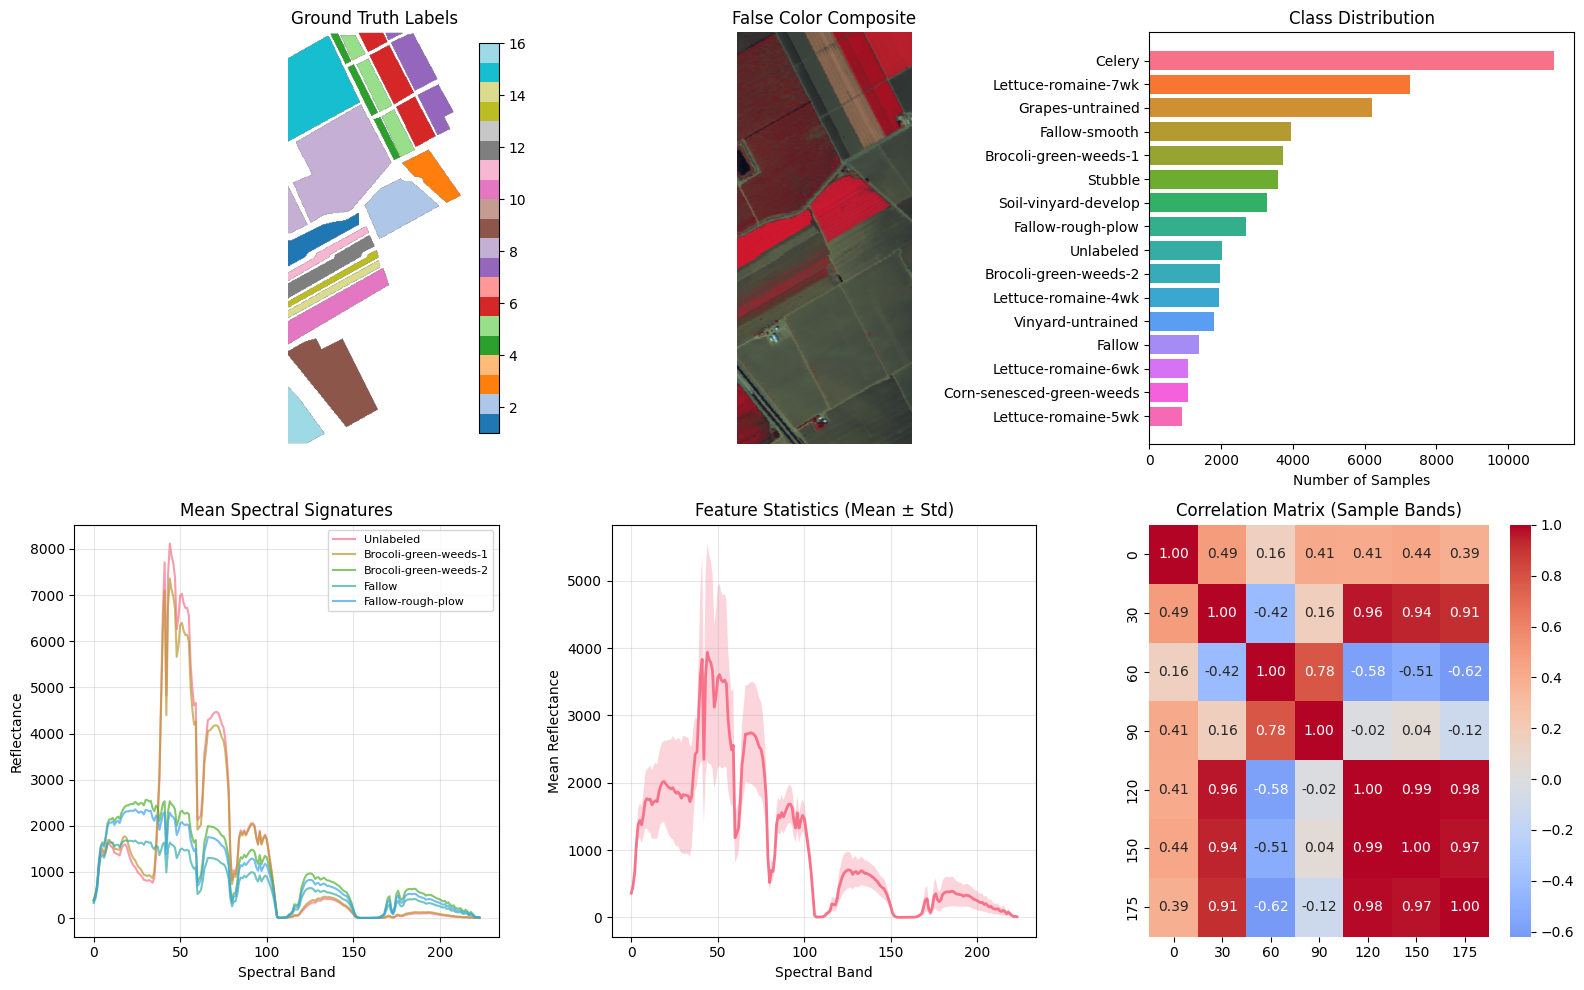

In [10]:

# ============================================================================
# SECTION 2: DATA EXPLORATION
# ============================================================================
print("\n📈 Data Exploration")
print("="*25)

def pixel_classification_preprocessing(X, y):
    """Preprocesses hyperspectral images for pixel classification.
    
    Reshapes the image and the ground truth data, keeps only the labeled
    pixels and renames the classes to ordered integers from 0.
    
    Parameters
    ----------
    X: NumPy array
        The image data.
    y: NumPy array
        The ground truth data.
    
    Returns
    -------
    X: NumPy array
        The prepreocessed pixels.
    y: NumPy array
        The prepreocessed labels.
    
    """
    # Reshape them to ignore spatiality
    X = X.reshape(-1, X.shape[2])
    y = y.reshape(-1)
    
    # Keep only labeled pixels
    X = X[y > 0, :]
    y = y[y > 0]
    
    # Rename clases to ordered integers from 0
    for new_class_num, old_class_num in enumerate(np.unique(y)):
        y[y == old_class_num] = new_class_num
    
    return X, y



X, y = pixel_classification_preprocessing(data,labels)

print(f"\nLabeled samples shape: {X.shape}")
print(f"Labels shape: {y.shape}")

# Class distribution
unique_classes, class_counts = np.unique(y, return_counts=True)
class_dist = pd.DataFrame({
    'Class': [class_names[c] for c in unique_classes],
    'Class ID': unique_classes,
    'Count': class_counts,
    'Percentage': (class_counts / len(y) * 100).round(2)
}).sort_values('Count', ascending=False)

print("\nClass Distribution:")
print(class_dist)

# Visualizations
fig = plt.figure(figsize=(16, 10))

# 1. Ground truth visualization
ax1 = plt.subplot(2, 3, 1)

# Make a copy and change its type to float
labels_vis = labels.copy().astype(float) 

# Now you can safely assign np.nan
labels_vis[labels_vis == 0] = np.nan 

im1 = ax1.imshow(labels_vis, cmap='tab20')
ax1.set_title('Ground Truth Labels')
ax1.axis('off')
plt.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)

# 2. False color composite (using 3 spectral bands)
ax2 = plt.subplot(2, 3, 2)
rgb_bands = data[:, :, [50, 30, 10]]  # Select bands for RGB
rgb_bands = (rgb_bands - rgb_bands.min()) / (rgb_bands.max() - rgb_bands.min())
ax2.imshow(rgb_bands)
ax2.set_title('False Color Composite')
ax2.axis('off')

# 3. Class distribution bar plot
ax3 = plt.subplot(2, 3, 3)
bars = ax3.barh(class_dist['Class'], class_dist['Count'], color=sns.color_palette('husl', len(class_dist)))
ax3.set_xlabel('Number of Samples')
ax3.set_title('Class Distribution')
ax3.invert_yaxis()

# 4. Spectral signature examples
ax4 = plt.subplot(2, 3, 4)
for class_id in unique_classes[:5]:
    class_samples = X[y == class_id]
    if len(class_samples) > 0:
        mean_spectrum = class_samples.mean(axis=0)
        ax4.plot(mean_spectrum, label=class_names[class_id], alpha=0.7)
ax4.set_xlabel('Spectral Band')
ax4.set_ylabel('Reflectance')
ax4.set_title('Mean Spectral Signatures')
ax4.legend(fontsize=8)
ax4.grid(True, alpha=0.3)

# 5. Feature statistics
ax5 = plt.subplot(2, 3, 5)
band_means = X.mean(axis=0)
band_stds = X.std(axis=0)
ax5.fill_between(range(X.shape[1]), band_means - band_stds, band_means + band_stds, alpha=0.3)
ax5.plot(band_means, linewidth=2)
ax5.set_xlabel('Spectral Band')
ax5.set_ylabel('Mean Reflectance')
ax5.set_title('Feature Statistics (Mean ± Std)')
ax5.grid(True, alpha=0.3)

# 6. Correlation heatmap (sample)
ax6 = plt.subplot(2, 3, 6)
sample_bands = [0, 30, 60, 90, 120, 150, 175]
corr_matrix = np.corrcoef(X[:, sample_bands].T)
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            xticklabels=sample_bands, yticklabels=sample_bands, ax=ax6)
ax6.set_title('Correlation Matrix (Sample Bands)')

plt.tight_layout()
plt.show()

In [11]:


# ============================================================================
# SECTION 3: DATA PREPROCESSING
# ============================================================================
print("\n🔧 Data Preprocessing")
print("="*25)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]:,} samples")
print(f"Test set size: {X_test.shape[0]:,} samples")
print(f"Number of features: {X_train.shape[1]}")

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Features scaled using StandardScaler")



🔧 Data Preprocessing
Training set size: 37,890 samples
Test set size: 16,239 samples
Number of features: 224
✅ Features scaled using StandardScaler


In [12]:

# ============================================================================
# SECTION 4: BASELINE MODEL TRAINING
# ============================================================================
print("\n🤖 Baseline Model Training")
print("="*35)

# Initialize models
print("\n1️⃣ Training XGBoost Baseline...")
start_time = time.time()
xgb_baseline = XGBClassifier(
    random_state=42,
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    verbosity=0,
    n_jobs=-1
)
xgb_baseline.fit(X_train, y_train)
xgb_train_time = time.time() - start_time
print(f"✅ XGBoost trained in {xgb_train_time:.2f} seconds")

print("\n2️⃣ Training LightGBM Baseline...")
start_time = time.time()
lgb_baseline = LGBMClassifier(
    random_state=42,
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    verbose=-1,
    n_jobs=-1
)
lgb_baseline.fit(X_train, y_train)
lgb_train_time = time.time() - start_time
print(f"✅ LightGBM trained in {lgb_train_time:.2f} seconds")

# Make predictions
xgb_pred = xgb_baseline.predict(X_test)
lgb_pred = lgb_baseline.predict(X_test)



🤖 Baseline Model Training

1️⃣ Training XGBoost Baseline...
✅ XGBoost trained in 13.28 seconds

2️⃣ Training LightGBM Baseline...
✅ LightGBM trained in 6.84 seconds



📊 Baseline Model Evaluation

XGBoost Baseline Performance:
  Accuracy:  0.9570
  F1 Score:  0.9568
  Precision: 0.9570
  Recall:    0.9570
  Kappa:     0.9521

LightGBM Baseline Performance:
  Accuracy:  0.9634
  F1 Score:  0.9632
  Precision: 0.9633
  Recall:    0.9634
  Kappa:     0.9592

📊 Baseline Comparison Summary:
            Model  Accuracy  F1 Score  Precision   Recall    Kappa  Training Time (s)
 XGBoost Baseline  0.957017  0.956808   0.957012 0.957017 0.952105          13.275978
LightGBM Baseline  0.963360  0.963223   0.963342 0.963360 0.959179           6.838320


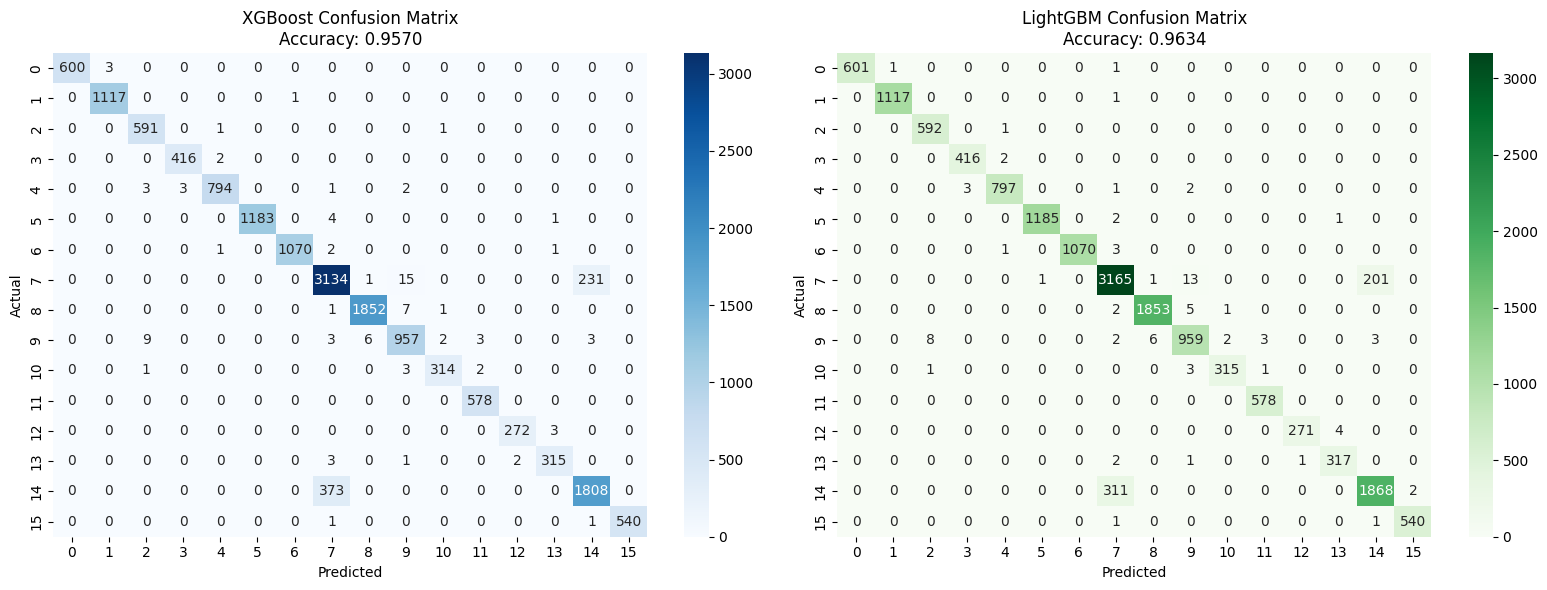


📋 XGBoost Classification Report:
                           precision    recall  f1-score   support

                Unlabeled       1.00      1.00      1.00       603
    Brocoli-green-weeds-1       1.00      1.00      1.00      1118
    Brocoli-green-weeds-2       0.98      1.00      0.99       593
                   Fallow       0.99      1.00      0.99       418
        Fallow-rough-plow       0.99      0.99      0.99       803
            Fallow-smooth       1.00      1.00      1.00      1188
                  Stubble       1.00      1.00      1.00      1074
                   Celery       0.89      0.93      0.91      3381
         Grapes-untrained       1.00      1.00      1.00      1861
     Soil-vinyard-develop       0.97      0.97      0.97       983
Corn-senesced-green-weeds       0.99      0.98      0.98       320
      Lettuce-romaine-4wk       0.99      1.00      1.00       578
      Lettuce-romaine-5wk       0.99      0.99      0.99       275
      Lettuce-romaine-6wk  

In [13]:

# ============================================================================
# SECTION 5: BASELINE MODEL EVALUATION
# ============================================================================
print("\n📊 Baseline Model Evaluation")
print("="*35)

def evaluate_model(y_true, y_pred, model_name):
    """Calculate and display model metrics"""
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='weighted')
    precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_true, y_pred, average='weighted')
    kappa = cohen_kappa_score(y_true, y_pred)
    
    print(f"\n{model_name} Performance:")
    print(f"  Accuracy:  {acc:.4f}")
    print(f"  F1 Score:  {f1:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  Kappa:     {kappa:.4f}")
    
    return {
        'Model': model_name,
        'Accuracy': acc,
        'F1 Score': f1,
        'Precision': precision,
        'Recall': recall,
        'Kappa': kappa
    }

# Evaluate both models
xgb_metrics = evaluate_model(y_test, xgb_pred, "XGBoost Baseline")
lgb_metrics = evaluate_model(y_test, lgb_pred, "LightGBM Baseline")

# Create comparison DataFrame
baseline_comparison = pd.DataFrame([xgb_metrics, lgb_metrics])
baseline_comparison['Training Time (s)'] = [xgb_train_time, lgb_train_time]

print("\n📊 Baseline Comparison Summary:")
print(baseline_comparison.to_string(index=False))

# Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# XGBoost confusion matrix
cm_xgb = confusion_matrix(y_test, xgb_pred)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title(f'XGBoost Confusion Matrix\nAccuracy: {xgb_metrics["Accuracy"]:.4f}')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# LightGBM confusion matrix
cm_lgb = confusion_matrix(y_test, lgb_pred)
sns.heatmap(cm_lgb, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title(f'LightGBM Confusion Matrix\nAccuracy: {lgb_metrics["Accuracy"]:.4f}')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

# Per-class performance
print("\n📋 XGBoost Classification Report:")
print(classification_report(y_test, xgb_pred, 
                          target_names=[class_names[i] for i in sorted(np.unique(y_test))]))

print("\n📋 LightGBM Classification Report:")
print(classification_report(y_test, lgb_pred,
                          target_names=[class_names[i] for i in sorted(np.unique(y_test))]))



🎯 Feature Importance Analysis


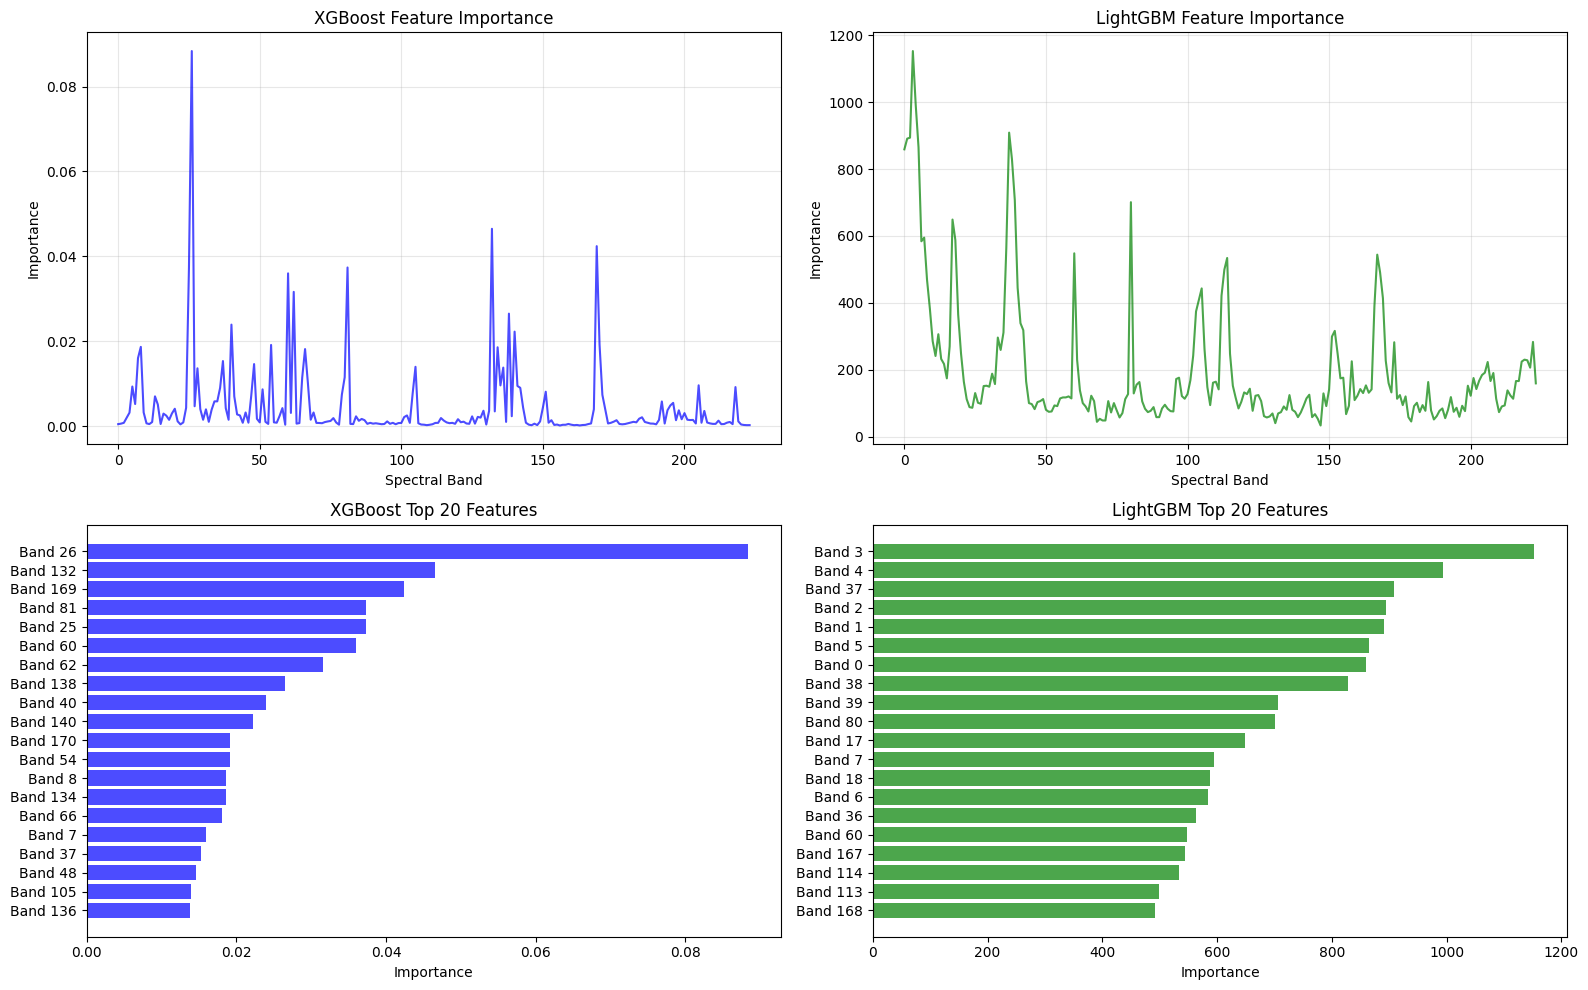


XGBoost Top 10 Bands: [26, 132, 169, 81, 25, 60, 62, 138, 40, 140]
LightGBM Top 10 Bands: [3, 4, 37, 2, 1, 5, 0, 38, 39, 80]


In [14]:

# ============================================================================
# SECTION 6: FEATURE IMPORTANCE ANALYSIS
# ============================================================================
print("\n🎯 Feature Importance Analysis")
print("="*35)

# Get feature importances
xgb_importance = xgb_baseline.feature_importances_
lgb_importance = lgb_baseline.feature_importances_

# Plot feature importance comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# XGBoost importance
axes[0, 0].plot(xgb_importance, color='blue', alpha=0.7)
axes[0, 0].set_title('XGBoost Feature Importance')
axes[0, 0].set_xlabel('Spectral Band')
axes[0, 0].set_ylabel('Importance')
axes[0, 0].grid(True, alpha=0.3)

# LightGBM importance
axes[0, 1].plot(lgb_importance, color='green', alpha=0.7)
axes[0, 1].set_title('LightGBM Feature Importance')
axes[0, 1].set_xlabel('Spectral Band')
axes[0, 1].set_ylabel('Importance')
axes[0, 1].grid(True, alpha=0.3)

# Top 20 features comparison
top_n = 20
xgb_top_idx = np.argsort(xgb_importance)[-top_n:]
lgb_top_idx = np.argsort(lgb_importance)[-top_n:]

axes[1, 0].barh(range(top_n), xgb_importance[xgb_top_idx], color='blue', alpha=0.7)
axes[1, 0].set_yticks(range(top_n))
axes[1, 0].set_yticklabels([f'Band {i}' for i in xgb_top_idx])
axes[1, 0].set_title(f'XGBoost Top {top_n} Features')
axes[1, 0].set_xlabel('Importance')

axes[1, 1].barh(range(top_n), lgb_importance[lgb_top_idx], color='green', alpha=0.7)
axes[1, 1].set_yticks(range(top_n))
axes[1, 1].set_yticklabels([f'Band {i}' for i in lgb_top_idx])
axes[1, 1].set_title(f'LightGBM Top {top_n} Features')
axes[1, 1].set_xlabel('Importance')

plt.tight_layout()
plt.show()

print(f"\nXGBoost Top 10 Bands: {xgb_top_idx[-10:][::-1].tolist()}")
print(f"LightGBM Top 10 Bands: {lgb_top_idx[-10:][::-1].tolist()}")


In [17]:
# ============================================================================
# SECTION 7: HYPERPARAMETER TUNING
# ============================================================================

import time
import joblib
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

print("\n🔍 Hyperparameter Tuning")
print("=" * 30)

# -----------------------------------------------------------
# Define parameter grids
# -----------------------------------------------------------
# Define parameter grids
xgb_param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [4, 6, 8],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9]
}

lgb_param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [4, 6, 8],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9]
}

# -----------------------------------------------------------
# Common search settings
# -----------------------------------------------------------
search_settings = {
    "scoring": "accuracy",
    "cv": 3,
    "n_jobs": -1,
    "verbose": 1,
    "n_iter": 20,
    "random_state": 42,
}

# -----------------------------------------------------------
# Utility function for tuning
# -----------------------------------------------------------
def tune_model(name, estimator, param_grid, X_train, y_train):
    print(f"\n🚀 Tuning {name} (this may take a while)...")
    start_time = time.time()

    search = RandomizedSearchCV(
        estimator=estimator,
        param_distributions=param_grid,
        **search_settings
    )

    # Use joblib backend for efficient parallelization
    # with joblib.parallel_backend("multiprocessing"):
    search.fit(X_train, y_train)

    elapsed = time.time() - start_time
    print(f"\n✅ {name} tuning completed in {elapsed:.2f} seconds")
    print(f"Best Parameters: {search.best_params_}")
    print(f"Best CV Accuracy: {search.best_score_:.4f}")

    return search, elapsed


# -----------------------------------------------------------
# XGBoost Tuning (no early stopping)
# -----------------------------------------------------------
xgb_estimator = XGBClassifier(
    random_state=42,
    verbosity=0,
    n_jobs=1,  # Disable internal parallelism
    tree_method="hist",  # faster on GPU or CPU
    device="cuda",       # use GPU if available
)

xgb_search, xgb_tuning_time = tune_model("XGBoost", xgb_estimator, xgb_param_grid, X_train, y_train)

# -----------------------------------------------------------
# LightGBM Tuning
# -----------------------------------------------------------
lgb_estimator = LGBMClassifier(
    random_state=42,
    verbose=-1,
    n_jobs=1,  # Disable internal parallelism
    device_type="gpu",  # optional: remove if not using GPU
)

lgb_search, lgb_tuning_time = tune_model("LightGBM", lgb_estimator, lgb_param_grid, X_train, y_train)



🔍 Hyperparameter Tuning

🚀 Tuning XGBoost (this may take a while)...
Fitting 3 folds for each of 20 candidates, totalling 60 fits


Traceback (most recent call last):
  File "/usr/lib/python3.13/multiprocessing/resource_tracker.py", line 295, in main
    raise ValueError(
        f'Cannot register {name} for automatic cleanup: '
        f'unknown resource type {rtype}')
ValueError: Cannot register /dev/shm/joblib_memmapping_folder_162731_c93f1c14523649029ac9962e23f515d5_38b4049a021e47d4a76c4008fd1c516e for automatic cleanup: unknown resource type folder
Traceback (most recent call last):
  File "/usr/lib/python3.13/multiprocessing/resource_tracker.py", line 295, in main
    raise ValueError(
        f'Cannot register {name} for automatic cleanup: '
        f'unknown resource type {rtype}')
ValueError: Cannot register /dev/shm/joblib_memmapping_folder_162731_9eda8eedabfe4e03afc9e1f930535161_257a6da01f314526bdc85a40ede4a2bf for automatic cleanup: unknown resource type folder
Traceback (most recent call last):
  File "/usr/lib/python3.13/multiprocessing/resource_tracker.py", line 295, in main
    raise ValueError(
   


✅ XGBoost tuning completed in 717.90 seconds
Best Parameters: {'subsample': 0.9, 'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.2, 'colsample_bytree': 0.8}
Best CV Accuracy: 0.9603

🚀 Tuning LightGBM (this may take a while)...
Fitting 3 folds for each of 20 candidates, totalling 60 fits


Traceback (most recent call last):
  File "/usr/lib/python3.13/multiprocessing/resource_tracker.py", line 295, in main
    raise ValueError(
        f'Cannot register {name} for automatic cleanup: '
        f'unknown resource type {rtype}')
ValueError: Cannot register /dev/shm/joblib_memmapping_folder_162731_f6b60fe20f554894909a2ce4b5d47c8f_8ba87f7bde7d4cad80d8b37e1a8ce8b1 for automatic cleanup: unknown resource type folder
Traceback (most recent call last):
  File "/usr/lib/python3.13/multiprocessing/resource_tracker.py", line 295, in main
    raise ValueError(
        f'Cannot register {name} for automatic cleanup: '
        f'unknown resource type {rtype}')
ValueError: Cannot register /dev/shm/joblib_memmapping_folder_162731_9eda8eedabfe4e03afc9e1f930535161_2b3df5d177054fd4903fa0add2b559c7 for automatic cleanup: unknown resource type folder
Traceback (most recent call last):
  File "/usr/lib/python3.13/multiprocessing/resource_tracker.py", line 295, in main
    raise ValueError(
   

KeyboardInterrupt: 

In [16]:
print("\n✅ Hyperparameter tuning completed for both models.")
# ============================================================================
print("\n📊 Tuning Summary")
print("="*30)

print(f"XGBoost Tuning Time: {xgb_tuning_time:.2f} seconds")
print(f"LightGBM Tuning Time: {lgb_tuning_time:.2f} seconds")

# Get best models
best_xgb = xgb_search.best_estimator_
best_lgb = lgb_search.best_estimator_

# Show best parameters
print("\nBest XGBoost Parameters:")
print(xgb_search.best_params_)

print("\nBest LightGBM Parameters:")
print(lgb_search.best_params_)


✅ Hyperparameter tuning completed for both models.

📊 Tuning Summary
XGBoost Tuning Time: 202.38 seconds
LightGBM Tuning Time: 146.40 seconds

Best XGBoost Parameters:
{'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.1}

Best LightGBM Parameters:
{'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.1}



📊 Optimized Model Evaluation

XGBoost Optimized Performance:
  Accuracy:  0.9348
  F1 Score:  0.9342
  Precision: 0.9343
  Recall:    0.9348
  Kappa:     0.9274

LightGBM Optimized Performance:
  Accuracy:  0.9437
  F1 Score:  0.9433
  Precision: 0.9436
  Recall:    0.9437
  Kappa:     0.9374

📊 Optimized Model Comparison:
             Model  Accuracy  F1 Score  Precision   Recall    Kappa
 XGBoost Optimized  0.934783  0.934173   0.934293 0.934783 0.927375
LightGBM Optimized  0.943734  0.943343   0.943596 0.943734 0.937360

📊 Complete Model Comparison:
             Model  Accuracy  F1 Score  Precision   Recall    Kappa  Training Time (s)
  XGBoost Baseline  0.937980  0.937061   0.937056 0.937980 0.930922           3.826034
 LightGBM Baseline  0.934783  0.934146   0.934745 0.934783 0.927391           1.895153
 XGBoost Optimized  0.934783  0.934173   0.934293 0.934783 0.927375         104.140865
LightGBM Optimized  0.943734  0.943343   0.943596 0.943734 0.937360          76.890242


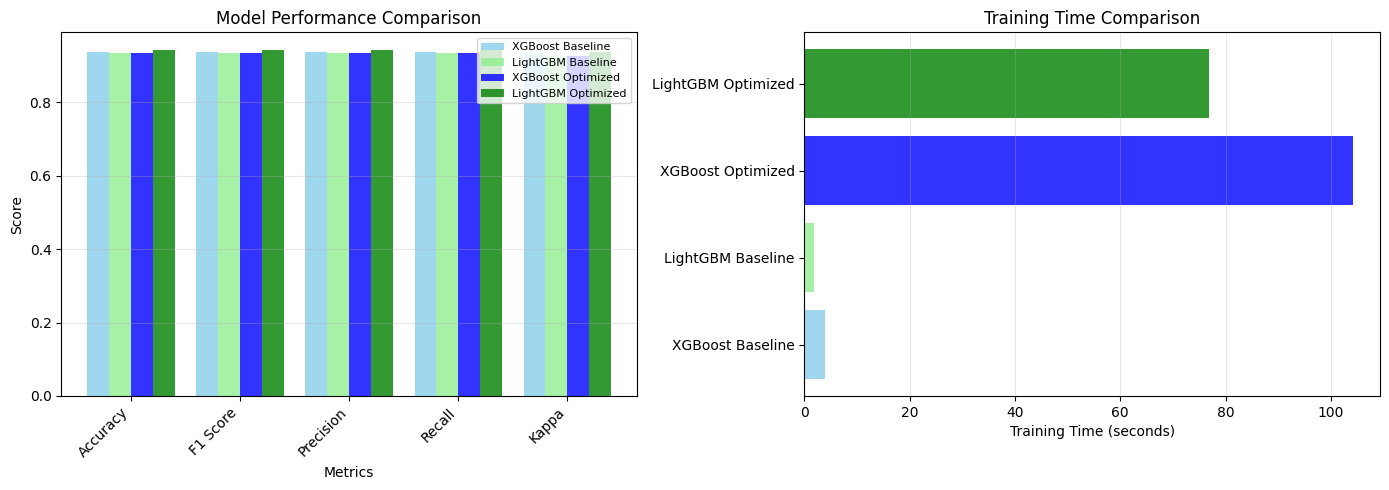

In [ ]:

# ============================================================================
# SECTION 8: OPTIMIZED MODEL EVALUATION
# ============================================================================
print("\n📊 Optimized Model Evaluation")
print("="*35)

# Get best models
best_xgb = xgb_search.best_estimator_
best_lgb = lgb_search.best_estimator_

# Make predictions
xgb_pred_opt = best_xgb.predict(X_test)
lgb_pred_opt = best_lgb.predict(X_test)

# Evaluate optimized models
xgb_metrics_opt = evaluate_model(y_test, xgb_pred_opt, "XGBoost Optimized")
lgb_metrics_opt = evaluate_model(y_test, lgb_pred_opt, "LightGBM Optimized")

# Create comparison DataFrame
optimized_comparison = pd.DataFrame([xgb_metrics_opt, lgb_metrics_opt])

print("\n📊 Optimized Model Comparison:")
print(optimized_comparison.to_string(index=False))

# Complete comparison (Baseline vs Optimized)
all_comparison = pd.DataFrame([
    xgb_metrics,
    lgb_metrics,
    xgb_metrics_opt,
    lgb_metrics_opt
])
all_comparison['Training Time (s)'] = [
    xgb_train_time, lgb_train_time, xgb_tuning_time, lgb_tuning_time
]

print("\n📊 Complete Model Comparison:")
print(all_comparison.to_string(index=False))

# Visualize improvements
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Metric comparison
metrics_to_plot = ['Accuracy', 'F1 Score', 'Precision', 'Recall', 'Kappa']
x_pos = np.arange(len(metrics_to_plot))
width = 0.2

for i, (model_name, color) in enumerate([
    ('XGBoost Baseline', 'skyblue'),
    ('LightGBM Baseline', 'lightgreen'),
    ('XGBoost Optimized', 'blue'),
    ('LightGBM Optimized', 'green')
]):
    model_data = all_comparison[all_comparison['Model'] == model_name]
    values = [model_data[metric].values[0] for metric in metrics_to_plot]
    axes[0].bar(x_pos + i*width, values, width, label=model_name, color=color, alpha=0.8)

axes[0].set_xlabel('Metrics')
axes[0].set_ylabel('Score')
axes[0].set_title('Model Performance Comparison')
axes[0].set_xticks(x_pos + width * 1.5)
axes[0].set_xticklabels(metrics_to_plot, rotation=45, ha='right')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3, axis='y')

# Training time comparison
model_names = all_comparison['Model'].values
training_times = all_comparison['Training Time (s)'].values
colors = ['skyblue', 'lightgreen', 'blue', 'green']
axes[1].barh(model_names, training_times, color=colors, alpha=0.8)
axes[1].set_xlabel('Training Time (seconds)')
axes[1].set_title('Training Time Comparison')
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()



🔄 Cross-Validation Analysis
Performing 5-fold cross-validation...


Traceback (most recent call last):
  File "/usr/lib/python3.13/multiprocessing/resource_tracker.py", line 295, in main
    raise ValueError(
        f'Cannot register {name} for automatic cleanup: '
        f'unknown resource type {rtype}')
ValueError: Cannot register /dev/shm/joblib_memmapping_folder_139600_3cceab84928d4595b7a8dbe87bda121a_b528056d1cc64aceb90db87c1ce4e6ac for automatic cleanup: unknown resource type folder
Traceback (most recent call last):
  File "/usr/lib/python3.13/multiprocessing/resource_tracker.py", line 295, in main
    raise ValueError(
        f'Cannot register {name} for automatic cleanup: '
        f'unknown resource type {rtype}')
ValueError: Cannot register /dev/shm/joblib_memmapping_folder_139600_90fe4adce4b8409285bd04df7e5a848a_d06558f5dbd54285bebdb7e4190c1837 for automatic cleanup: unknown resource type folder
Traceback (most recent call last):
  File "/usr/lib/python3.13/multiprocessing/resource_tracker.py", line 295, in main
    raise ValueError(
   


XGBoost CV Accuracy: 0.9309 (+/- 0.0225)
LightGBM CV Accuracy: 0.9380 (+/- 0.0238)


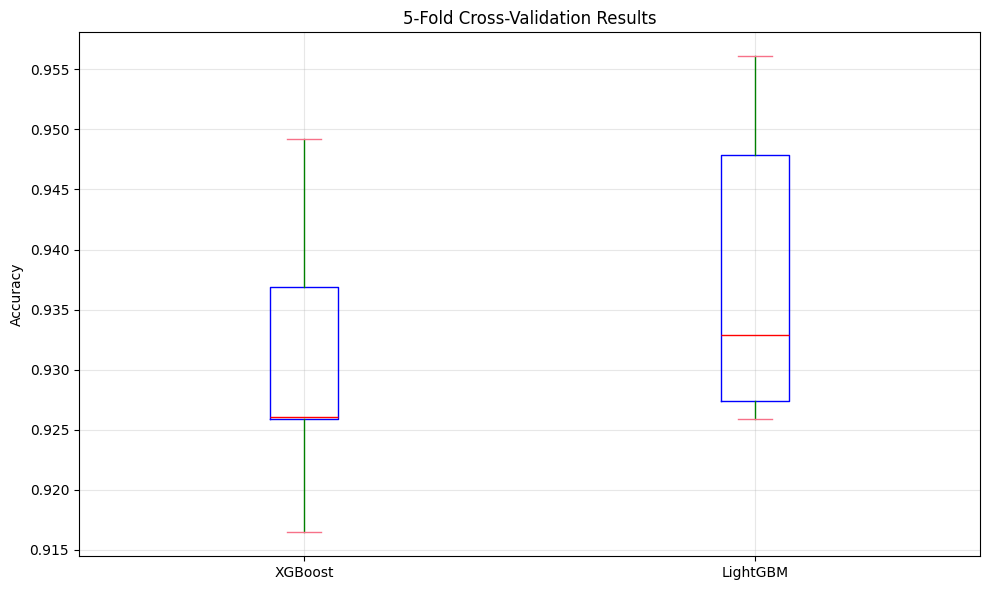

In [ ]:

# ============================================================================
# SECTION 9: CROSS-VALIDATION ANALYSIS
# ============================================================================
print("\n🔄 Cross-Validation Analysis")
print("="*35)

# Perform 5-fold CV on optimized models
print("Performing 5-fold cross-validation...")

xgb_cv_scores = cross_val_score(best_xgb, X_train, y_train, cv=5, scoring='accuracy', n_jobs=-1)
lgb_cv_scores = cross_val_score(best_lgb, X_train, y_train, cv=5, scoring='accuracy', n_jobs=-1)

print(f"\nXGBoost CV Accuracy: {xgb_cv_scores.mean():.4f} (+/- {xgb_cv_scores.std() * 2:.4f})")
print(f"LightGBM CV Accuracy: {lgb_cv_scores.mean():.4f} (+/- {lgb_cv_scores.std() * 2:.4f})")

# Plot CV results
fig, ax = plt.subplots(figsize=(10, 6))
cv_data = pd.DataFrame({
    'XGBoost': xgb_cv_scores,
    'LightGBM': lgb_cv_scores
})
cv_data.plot(kind='box', ax=ax, color=dict(boxes='blue', whiskers='green', medians='red'))
ax.set_ylabel('Accuracy')
ax.set_title('5-Fold Cross-Validation Results')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:

# ============================================================================
# SECTION 10: PREDICTION VISUALIZATION
# ============================================================================
print("\n🗺️ Prediction Visualization")
print("="*30)

# Predict on all pixels
print("Generating predictions for entire image...")
X_all_scaled = scaler.transform(X_all)
xgb_pred_all = best_xgb.predict(X_all_scaled)
lgb_pred_all = best_lgb.predict(X_all_scaled)

# Reshape predictions to image shape
xgb_pred_map = xgb_pred_all.reshape(height, width)
lgb_pred_map = lgb_pred_all.reshape(height, width)

# Set unlabeled pixels to 0
xgb_pred_map[~labeled_mask.reshape(height, width)] = 0
lgb_pred_map[~labeled_mask.reshape(height, width)] = 0

# Visualize predictions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Ground truth
labels_vis = labels.copy()
labels_vis[labels_vis == 0] = np.nan
im1 = axes[0].imshow(labels_vis, cmap='tab20', vmin=1, vmax=13)
axes[0].set_title('Ground Truth')
axes[0].axis('off')
plt.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)

# XGBoost predictions
xgb_vis = xgb_pred_map.copy().astype(float)
xgb_vis[xgb_vis == 0] = np.nan
im2 = axes[1].imshow(xgb_vis, cmap='tab20', vmin=1, vmax=13)
axes[1].set_title(f'XGBoost Predictions\nAccuracy: {xgb_metrics_opt["Accuracy"]:.4f}')
axes[1].axis('off')
plt.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)

# LightGBM predictions
lgb_vis = lgb_pred_map.copy().astype(float)
lgb_vis[lgb_vis == 0] = np.nan
im3 = axes[2].imshow(lgb_vis, cmap='tab20', vmin=1, vmax=13)
axes[2].set_title(f'LightGBM Predictions\nAccuracy: {lgb_metrics_opt["Accuracy"]:.4f}')
axes[2].axis('off')
plt.colorbar(im3, ax=axes[2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()



🗺️ Prediction Visualization
Generating predictions for entire image...


NameError: name 'X_all' is not defined

In [ ]:

# ============================================================================
# SECTION 11: MODEL SAVING
# ============================================================================
print("\n💾 Saving Models")
print("="*20)

# Save models
with open('best_xgboost_ksc_model.pkl', 'wb') as f:
    pickle.dump(best_xgb, f)

with open('best_lightgbm_ksc_model.pkl', 'wb') as f:
    pickle.dump(best_lgb, f)

with open('ksc_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("✅ Best XGBoost model saved as 'best_xgboost_ksc_model.pkl'")
print("✅ Best LightGBM model saved as 'best_lightgbm_ksc_model.pkl'")
print("✅ Feature scaler saved as 'ksc_scaler.pkl'")


In [ ]:

# ============================================================================
# SECTION 12: FINAL SUMMARY
# ============================================================================
print("\n🎉 Analysis Complete!")
print("="*25)

# Determine winner
if xgb_metrics_opt['Accuracy'] > lgb_metrics_opt['Accuracy']:
    winner = "XGBoost"
    winner_acc = xgb_metrics_opt['Accuracy']
else:
    winner = "LightGBM"
    winner_acc = lgb_metrics_opt['Accuracy']

print(f"\n🏆 Winner: {winner} with {winner_acc:.4f} accuracy")

print("\n📊 Final Summary:")
print(f"Dataset: Kennedy Space Center (KSC)")
print(f"  • Image size: {height} x {width} pixels")
print(f"  • Spectral bands: {bands}")
print(f"  • Labeled samples: {len(y):,}")
print(f"  • Number of classes: {len(np.unique(y))}")

print(f"\nBest XGBoost Performance:")
print(f"  • Accuracy: {xgb_metrics_opt['Accuracy']:.4f}")
print(f"  • F1 Score: {xgb_metrics_opt['F1 Score']:.4f}")
print(f"  • Kappa: {xgb_metrics_opt['Kappa']:.4f}")

print(f"\nBest LightGBM Performance:")
print(f"  • Accuracy: {lgb_metrics_opt['Accuracy']:.4f}")
print(f"  • F1 Score: {lgb_metrics_opt['F1 Score']:.4f}")
print(f"  • Kappa: {lgb_metrics_opt['Kappa']:.4f}")

print("\n✨ Both models are ready for deployment!")